<a href="https://colab.research.google.com/github/kondapallijayasri739-glitch/projects_analysis/blob/main/Students_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

data = pd.read_csv(next(iter(uploaded)))
print(data.head())

Saving StudentsPerformance (1).csv to StudentsPerformance (1).csv
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
le = LabelEncoder()

data["gender"] = le.fit_transform(data["gender"])
data["race/ethnicity"] = le.fit_transform(data["race/ethnicity"])
data["parental level of education"] = le.fit_transform(data["parental level of education"])
data["lunch"] = le.fit_transform(data["lunch"])
data["test preparation course"] = le.fit_transform(data["test preparation course"])

In [ ]:
X = data[[
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "reading score",
    "writing score"
]]

y = data["math score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 4.70082380952381
R2 Score: 0.8487940184356789


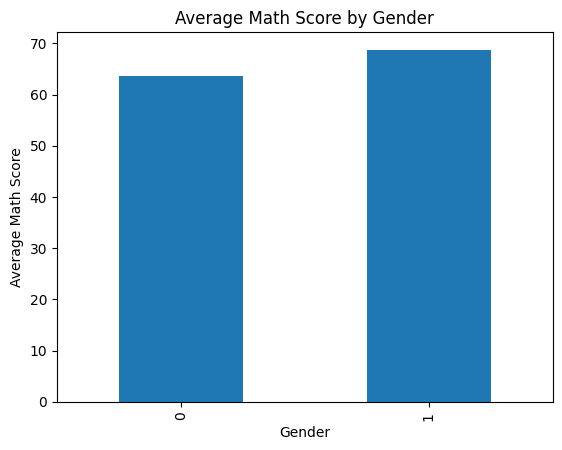

In [ ]:
data.groupby("gender")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Math Score")
plt.show()

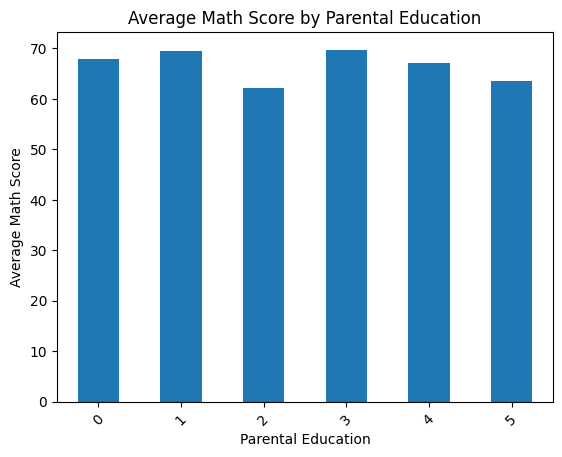

In [ ]:
data.groupby("parental level of education")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Math Score")
plt.xticks(rotation=45)
plt.show()

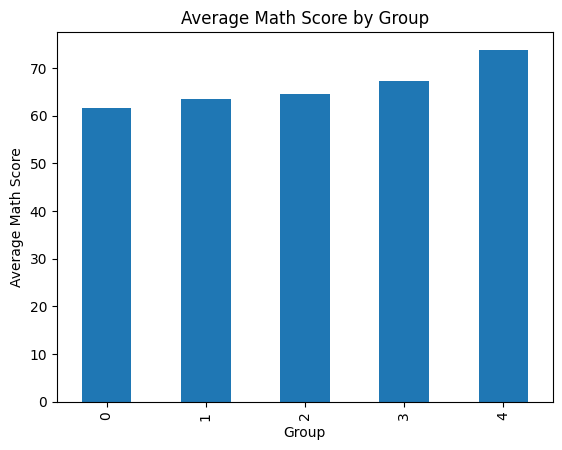

In [ ]:
data.groupby("race/ethnicity")["math score"].mean().plot(kind="bar")
plt.title("Average Math Score by Group")
plt.xlabel("Group")
plt.ylabel("Average Math Score")
plt.show()

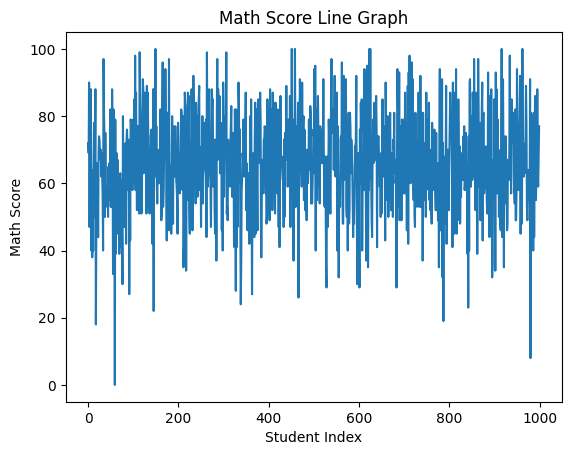

In [ ]:
plt.plot(data["math score"])
plt.title("Math Score Line Graph")
plt.xlabel("Student Index")
plt.ylabel("Math Score")
plt.show()

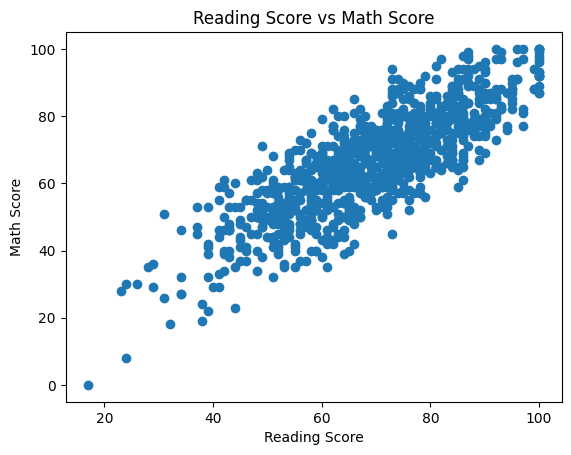

In [ ]:
plt.scatter(data["reading score"], data["math score"])
plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.show()